In [2]:
from nhr import *

In [14]:
def g_circle(x):
    """
    Circle constraint function.
    feasible: x0^2 + x1^2 - 1 <= 0
    """
    return np.array([
        x[0] ** 2 + x[1] ** 2 - 1.0
    ])


def Jg_circle(x):
    """
    Jacobian of the circle constraint function.
    We need it for the Hit-and-Run algorithm to sample from the feasible region defined by the constraint.
    Returns the gradient of g_circle at point x.
    """
    return np.array([
        [2.0 * x[0], 2.0 * x[1]]
    ])


def f_zero(x):
    """
    Objective function (zero function).
    We don't have a specific objective to optimize, we just want to sample from the feasible region defined by the constraint.
    """
    return 0.0

def f_perimeter(x):
    """
    Objective function (perimeter of the circle).
    We want to sample from the feasible region defined by the constraint and maximize the perimeter of the circle.
    """
    return -2.0 * np.pi * np.sqrt(x[0] ** 2 + x[1] ** 2)


x0 = np.array([0.0, 0.0])
lower = np.array([-1.2, -1.2])
upper = np.array([1.2, 1.2])

options = NHROptions(
    num_samples=1000,
    burn_in=200,
    thinning=1,
    delta_max=0.5,
    random_seed=1,
    verbose=True,
)

samples, diagnostics = nhr_sample(
    x0=x0,
    g=g_circle,
    Jg=Jg_circle,
    f=f_perimeter,
    lower=lower,
    upper=upper,
    options=options,
)

step 00000/1200 | samples 00000/1000 | last: mh_accept
step 00120/1200 | samples 00000/1000 | last: mh_accept
step 00240/1200 | samples 00041/1000 | last: mh_accept
step 00360/1200 | samples 00161/1000 | last: mh_accept
step 00480/1200 | samples 00281/1000 | last: mh_accept
step 00600/1200 | samples 00401/1000 | last: mh_accept
step 00720/1200 | samples 00521/1000 | last: mh_accept
step 00840/1200 | samples 00641/1000 | last: mh_accept
step 00960/1200 | samples 00761/1000 | last: mh_reject
step 01080/1200 | samples 00881/1000 | last: mh_accept


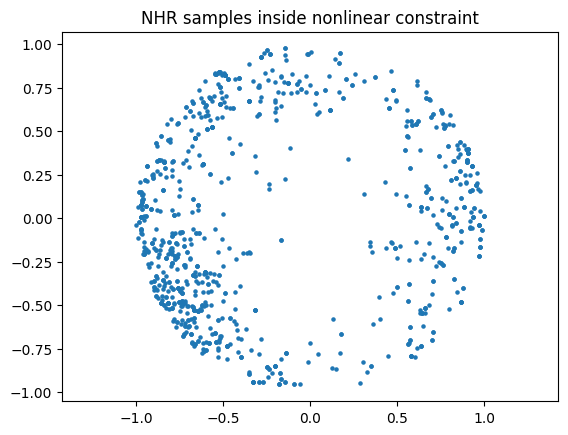

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(samples[:, 0], samples[:, 1], s=5)
plt.axis("equal")
plt.title("NHR samples inside nonlinear constraint")
plt.show()